### Data Loading

In [1]:
# Load data

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = 'data'
# 1. Load the data
# df_elec = pd.read_csv('data/electricity_short.csv', parse_dates=['timestamp'], index_col='timestamp')
# df_elec = pd.read_csv('data/electricity.csv', parse_dates=['timestamp'], index_col='timestamp')
df_elec = pd.read_csv('data/electricity_clean.csv', parse_dates=['timestamp'], index_col='timestamp')

df_meta = pd.read_csv('data/metadata.csv')

print("Data loaded")

Data loaded


### Data shape

Number of Buildings:  1027
Number of Timestamps: 17544
Data Range:           From 2016-01-01 00:00 to 2017-12-31 23:00

Missing values in electricity data: 353226
--- UNIQUE SITES ---
['Robin' 'Fox' 'Rat' 'Bear' 'Lamb' 'Peacock' 'Moose' 'Bull' 'Crow' 'Wolf'
 'Hog' 'Cockatoo' 'Mouse']
Unique Primary Space Usage:
['Lodging/residential' 'Education' 'Office'
 'Entertainment/public assembly' 'Other' 'Retail' 'Parking'
 'Public services' 'Warehouse/storage' 'Food sales and service'
 'Religious worship' 'Healthcare' 'Utility' 'Technology/science'
 'Manufacturing/industrial' 'Services' nan]

Unique Sub Primary Space Usage:
['Residence Hall' 'Research' 'Office' 'Classroom' 'Stadium'
 'Residence Hall\t' 'Other' 'Retail' 'Parking Garage' 'College Classroom'
 'College Laboratory' 'Dormitory' 'Gymnasium' 'Library' 'Police Station'
 'Museum' 'Auditorium' 'Warehouse' 'Fitness Center' 'Restaurant'
 'Student Union' 'Athletic Field' 'Chapel' 'Sports Stadium'
 'Health Services' 'Theater' 'Primary/Seconda

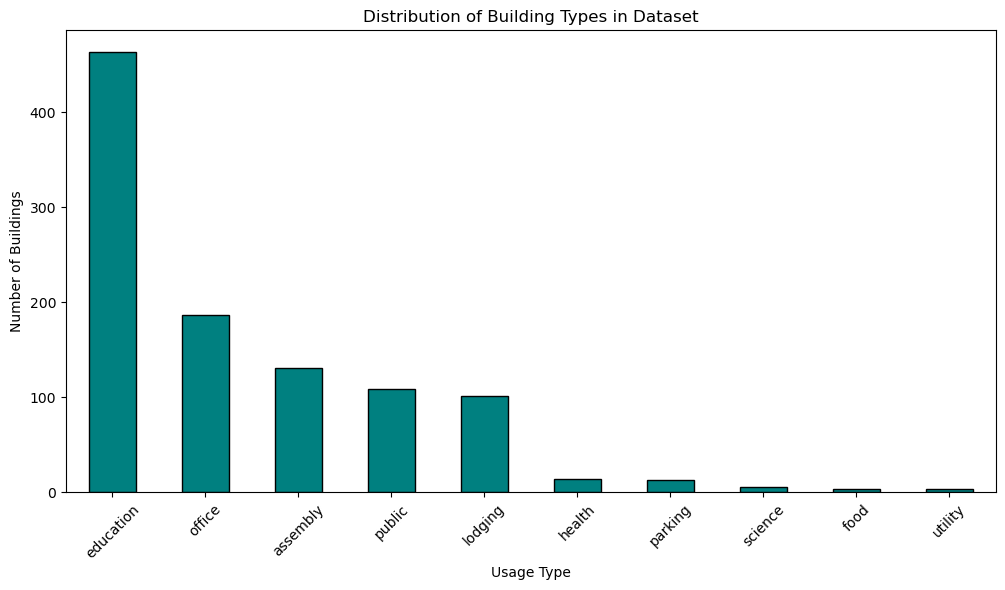

In [2]:
# Show columns

import pandas as pd

# Basic Data Inspection
# 1. Get the number of buildings (columns)
num_buildings = len(df_elec.columns)

# 2. Get the number of timestamps (rows)
num_timestamps = len(df_elec.index)

# 3. Get the date range for context
start_date = df_elec.index.min().strftime('%Y-%m-%d %H:%M')
end_date = df_elec.index.max().strftime('%Y-%m-%d %H:%M')

print(f"Number of Buildings:  {num_buildings}")
print(f"Number of Timestamps: {num_timestamps}")
print(f"Data Range:           From {start_date} to {end_date}")
print("\nMissing values in electricity data:", df_elec.isnull().sum().sum())

# Extract the parts from the column headers
# We skip the index and split the strings by the underscore
building_info = [col.split('_') for col in df_elec.columns]

# Create a clean DataFrame of these components
df_names = pd.DataFrame(building_info, columns=['Site', 'Usage', 'Name'])

# Print unique Sites and Usages found
print("--- UNIQUE SITES ---")
print(df_names['Site'].unique())

# Print unique values for primary usage
print("Unique Primary Space Usage:")
print(df_meta['primaryspaceusage'].unique())

# Print unique values for sub primary usage
print("\nUnique Sub Primary Space Usage:")
print(df_meta['sub_primaryspaceusage'].unique())

# Assuming df_names is the DataFrame we created earlier by splitting the column names
usage_counts = df_names['Usage'].value_counts()

print("--- BUILDING COUNT BY USAGE TYPE ---")
print(usage_counts)

# Optional: Visualize the distribution to see the "Major" vs "Minor" categories
usage_counts.plot(kind='bar', figsize=(12, 6), color='teal', edgecolor='black')
plt.title('Distribution of Building Types in Dataset')
plt.ylabel('Number of Buildings')
plt.xlabel('Usage Type')
plt.xticks(rotation=45)
plt.show()


### Graphs

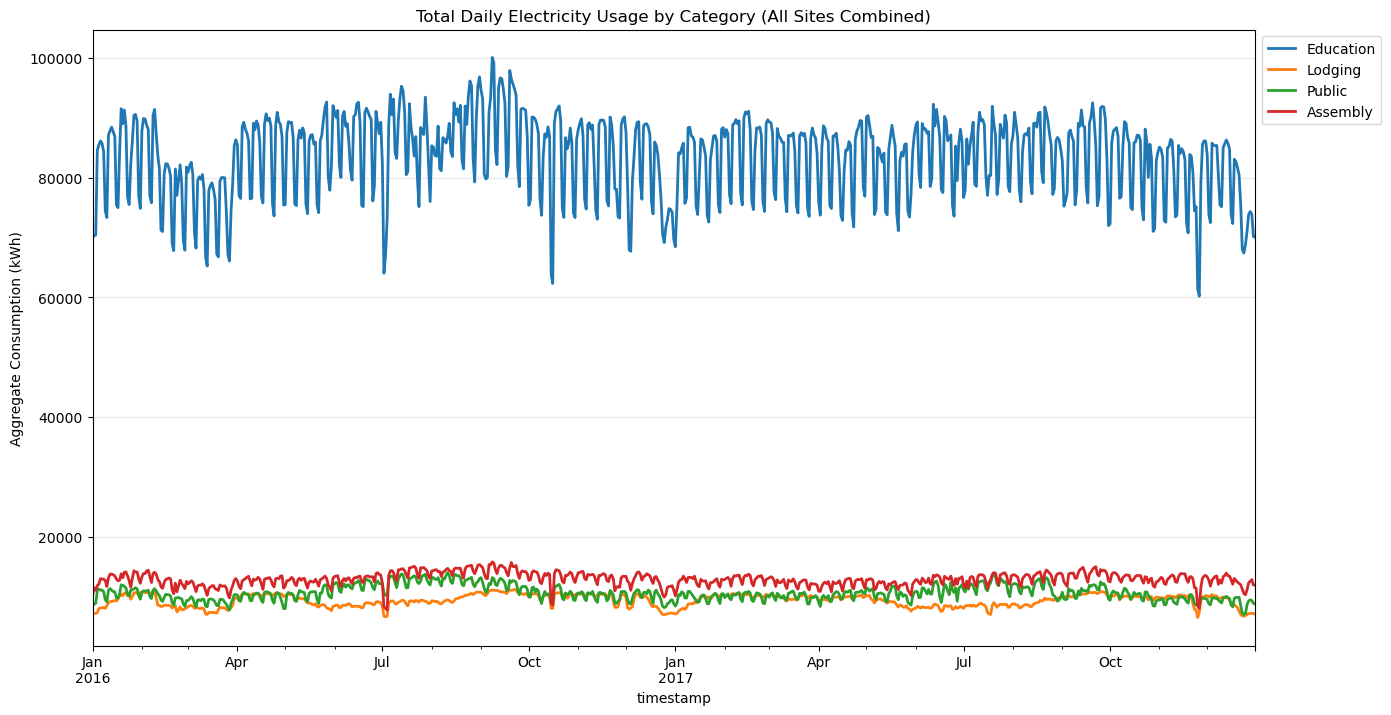

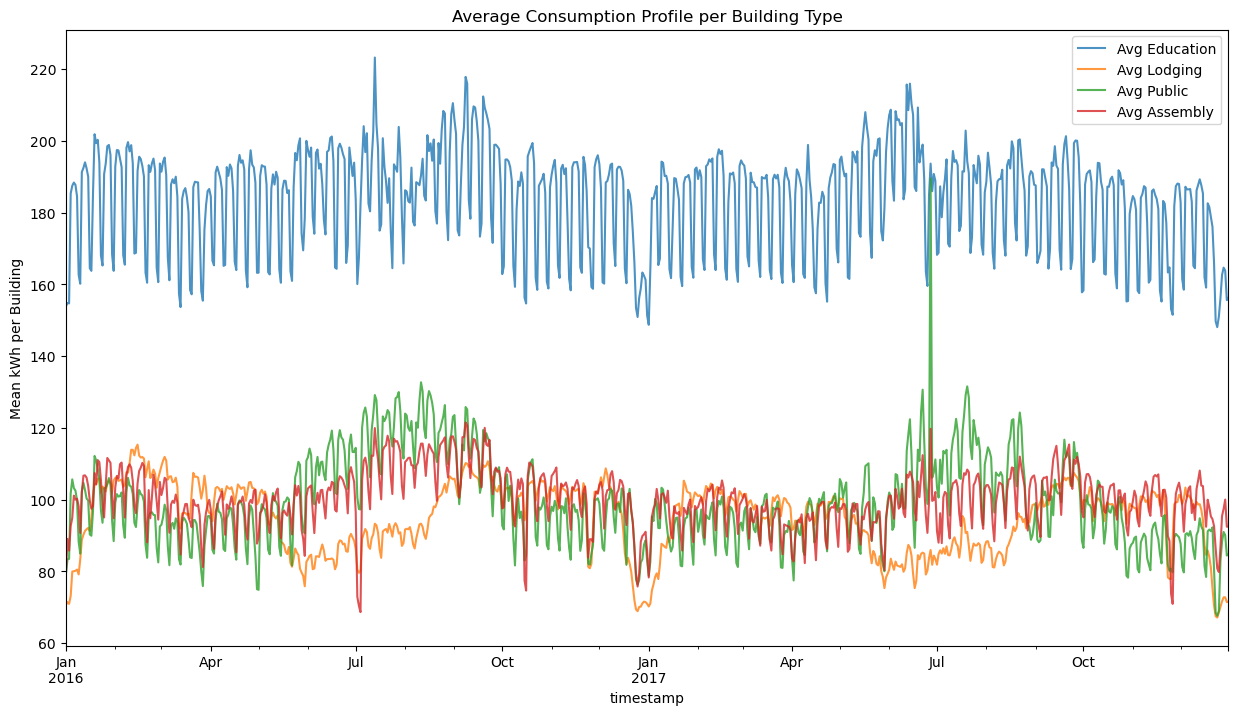

In [3]:
# Electricity usage graphs year round

# Define the categories you want to see
categories = [
    'education', 
    # 'office', 
    'lodging', 
    # 'parking', 
    'public', 
    'assembly', 
    # 'utility', 
    # 'food',
]

plt.figure(figsize=(15, 8))

for cat in categories:
    # Select all columns that have the category name in them
    cat_cols = [col for col in df_elec.columns if f'_{cat}_' in col.lower()]
    
    if cat_cols:
        # Sum all buildings in this category and resample to Daily for a cleaner line
        df_elec[cat_cols].sum(axis=1).resample('D').mean().plot(label=cat.title(), linewidth=2)

plt.title('Total Daily Electricity Usage by Category (All Sites Combined)')
plt.ylabel('Aggregate Consumption (kWh)')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(axis='y', alpha=0.3)
plt.show()

plt.figure(figsize=(15, 8))

for cat in categories:
    cat_cols = [col for col in df_elec.columns if f'_{cat}_' in col.lower()]
    
    if cat_cols:
        # Mean across the columns gives you the "Average Building" of that type
        df_elec[cat_cols].mean(axis=1).resample('D').mean().plot(label=f'Avg {cat.title()}', alpha=0.8)

plt.title('Average Consumption Profile per Building Type')
plt.ylabel('Mean kWh per Building')
plt.legend()
plt.show()

### Electricity usage by day

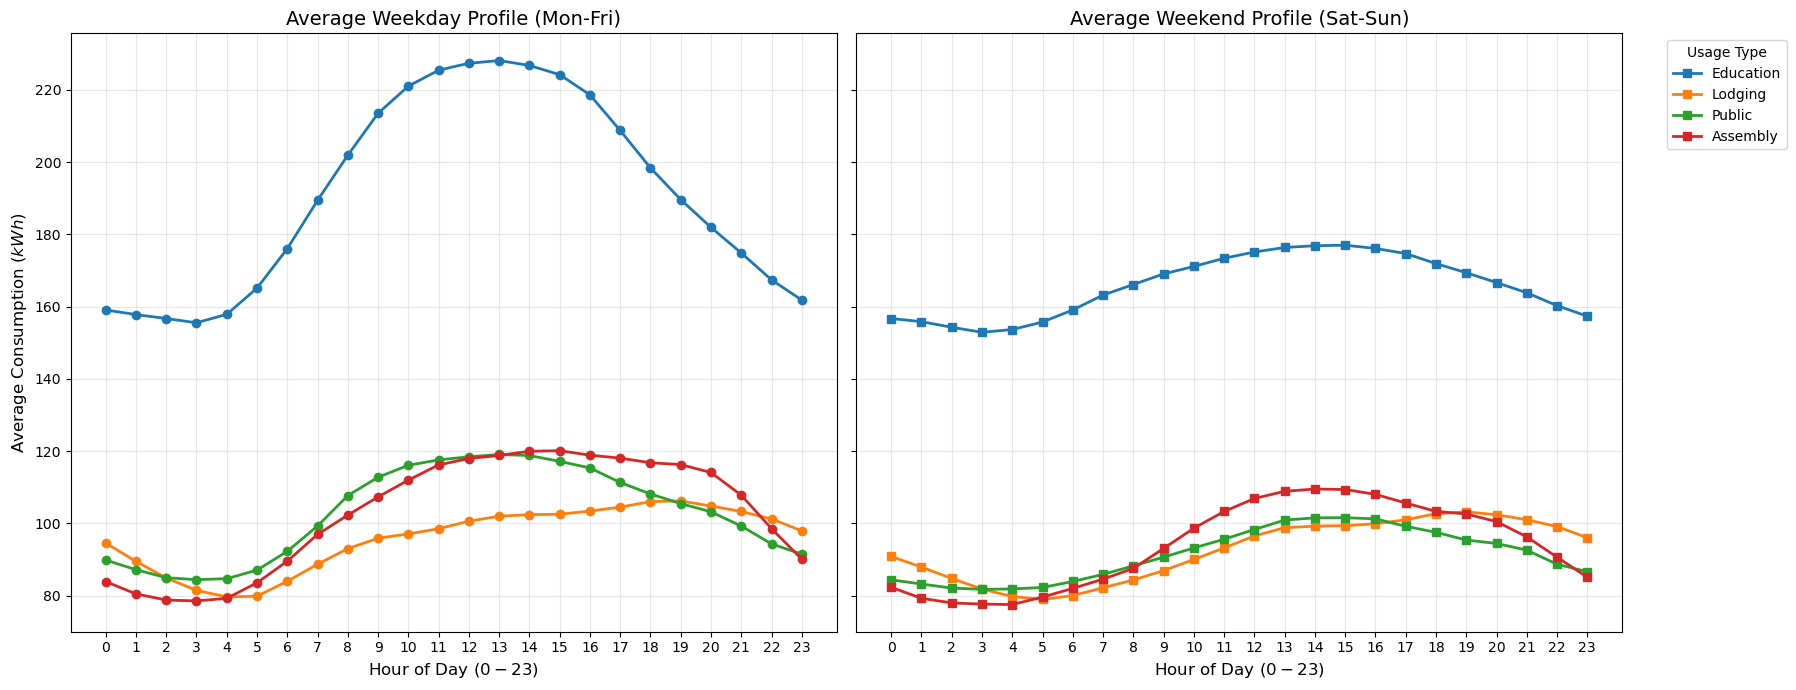

In [4]:
import matplotlib.pyplot as plt

# Define categories
# categories = ['education', 'office', 'lodging', 'public', 'assembly']

# Split the data
is_weekday = df_elec.index.dayofweek < 5
df_weekday = df_elec[is_weekday]
df_weekend = df_elec[~is_weekday]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

for cat in categories:
    cat_cols = [col for col in df_elec.columns if f'_{cat}_' in col.lower()]
    if cat_cols:
        # Calculate Hourly Profile for Weekdays
        weekday_profile = df_weekday[cat_cols].mean(axis=1).groupby(df_weekday.index.hour).mean()
        ax1.plot(weekday_profile.index, weekday_profile.values, label=cat.title(), linewidth=2, marker='o')
        
        # Calculate Hourly Profile for Weekends
        weekend_profile = df_weekend[cat_cols].mean(axis=1).groupby(df_weekend.index.hour).mean()
        ax2.plot(weekend_profile.index, weekend_profile.values, label=cat.title(), linewidth=2, marker='s')

# Formatting Left Plot (Weekday)
ax1.set_title('Average Weekday Profile (Mon-Fri)', fontsize=14)
ax1.set_ylabel('Average Consumption ($kWh$)', fontsize=12)
ax1.set_xlabel('Hour of Day ($0-23$)', fontsize=12)
ax1.set_xticks(range(0, 24))
ax1.grid(True, alpha=0.3)

# Formatting Right Plot (Weekend)
ax2.set_title('Average Weekend Profile (Sat-Sun)', fontsize=14)
ax2.set_xlabel('Hour of Day ($0-23$)', fontsize=12)
ax2.set_xticks(range(0, 24))
ax2.grid(True, alpha=0.3)

plt.legend(title="Usage Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Energy usage by day of week

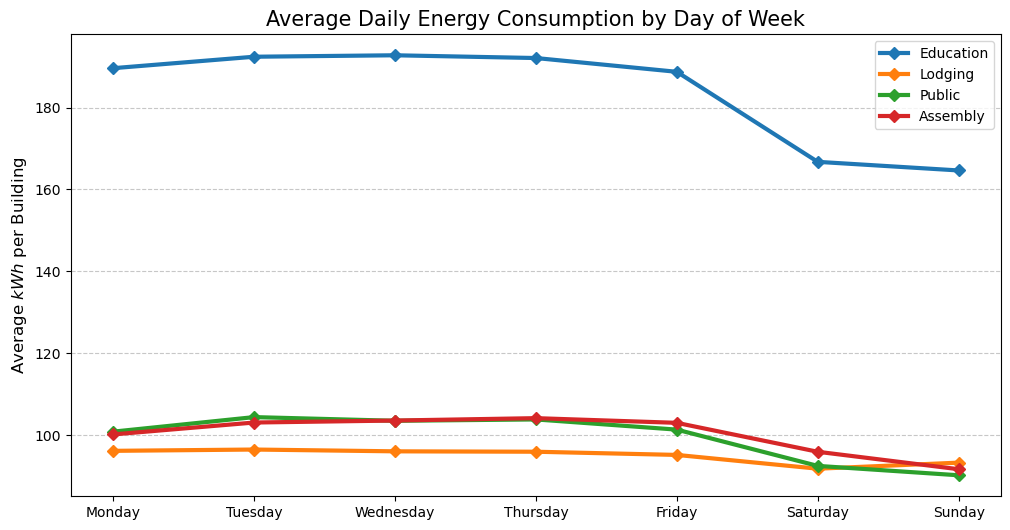

In [5]:
plt.figure(figsize=(12, 6))

days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

for cat in categories:
    cat_cols = [col for col in df_elec.columns if f'_{cat}_' in col.lower()]
    if cat_cols:
        # Group by day of week (0=Mon, 6=Sun)
        weekly_trend = df_elec[cat_cols].mean(axis=1).groupby(df_elec.index.dayofweek).mean()
        
        plt.plot(days, weekly_trend.values, label=cat.title(), linewidth=3, marker='D')

plt.title('Average Daily Energy Consumption by Day of Week', fontsize=15)
plt.ylabel('Average $kWh$ per Building', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.show()

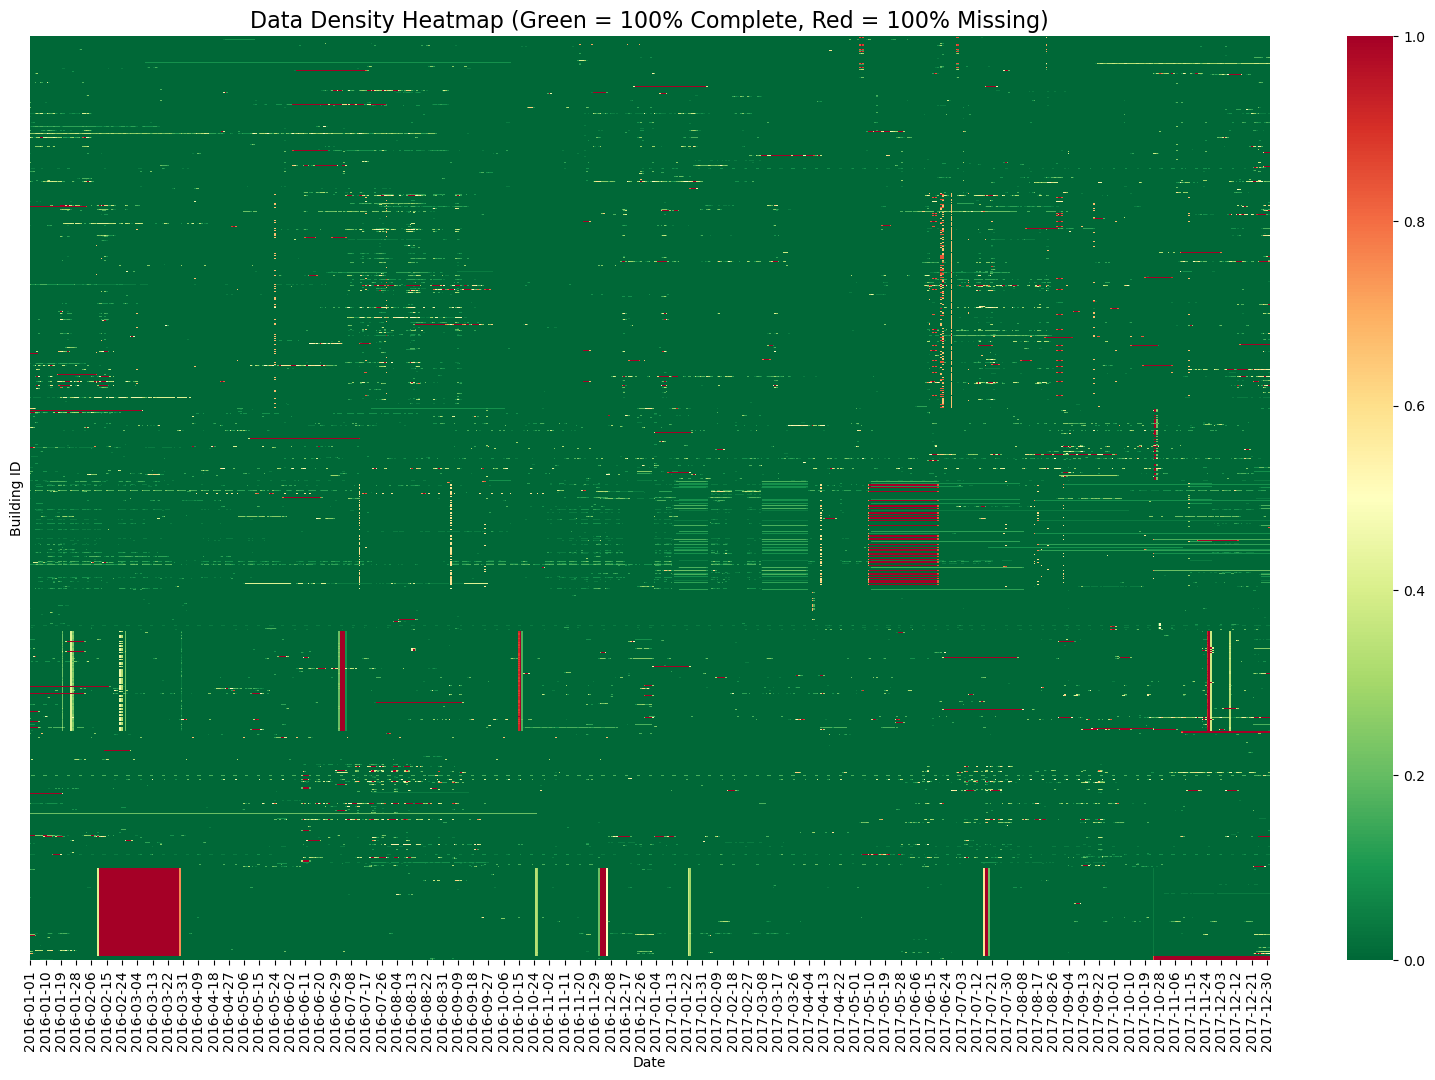

Plotting took: 1.21 seconds
Top 100 buildings with the most missing data (%):
Rat_public_Caroline          9.946420
Lamb_education_Salvador      9.883721
Lamb_education_Marty         9.838121
Lamb_education_Kasha         9.701322
Mouse_health_Justin          9.530324
Bear_education_Nanette       9.501824
Mouse_health_Estela          9.490424
Mouse_lodging_Vicente        9.416325
Mouse_health_Modesto         9.416325
Lamb_education_Nathan        9.365025
Cockatoo_lodging_Elvia       9.023028
Cockatoo_public_Harland      8.948928
Bear_education_Destiny       8.937528
Lamb_education_Kayla         8.732330
Cockatoo_public_Valerie      8.692430
Cockatoo_education_Lionel    8.686731
Lamb_education_Chet          8.652531
Bull_lodging_Danielle        8.601231
Cockatoo_office_Gail         8.567031
Cockatoo_public_Leah         8.538532
dtype: float64


In [6]:
# Missing value head map

import seaborn as sns
import matplotlib.pyplot as plt
import time

# 1. Calculate the fraction of missing values per day
daily_null_fraction = df_elec.isnull().resample('D').mean().T

# 2. Format the columns (dates) to YYYY-MM-DD strings
daily_null_fraction.columns = [d.strftime('%Y-%m-%d') for d in daily_null_fraction.columns]

start_time = time.time()
plt.figure(figsize=(20, 12))

# 3. Create the heatmap
sns.heatmap(
    daily_null_fraction, 
    cmap='RdYlGn_r', 
    vmax=1.0, vmin=0.0,
    # xticklabels=30, # shows a date label every 30 days
    yticklabels=False, # Remove building names
) 

plt.title('Data Density Heatmap (Green = 100% Complete, Red = 100% Missing)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Building ID')
# plt.xticks(rotation=45) # Rotate for better readability
plt.show()
end_time = time.time()
print(f"Plotting took: {end_time - start_time:.2f} seconds")

# 4. Quick Summary of the worst buildings
missing_counts = df_elec.isnull().mean().sort_values(ascending=False)
print("Top 100 buildings with the most missing data (%):")
print(missing_counts.head(20) * 100)